Dados extraídos com sucesso!
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber opt

/tmp/ipykernel_1083/1688193093.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dados.fillna(method="ffill", inplace=True)


        customerid churn                                           customer  \
count         7267  7267                                               7267   
unique        7267     3                                                891   
top     9995-HOTOH    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
freq             1  5174                                                223   

                                                 phone  \
count                                             7267   
unique                                               3   
top     {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
freq                                              3495   

                                                 internet  \
count                                                7267   
unique                                                129   
top     {'InternetService': 'No', 'OnlineSecurity': 'N...   
freq                                                 1581   

       

/tmp/ipykernel_1083/1688193093.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="churn", data=dados, palette="Set2")


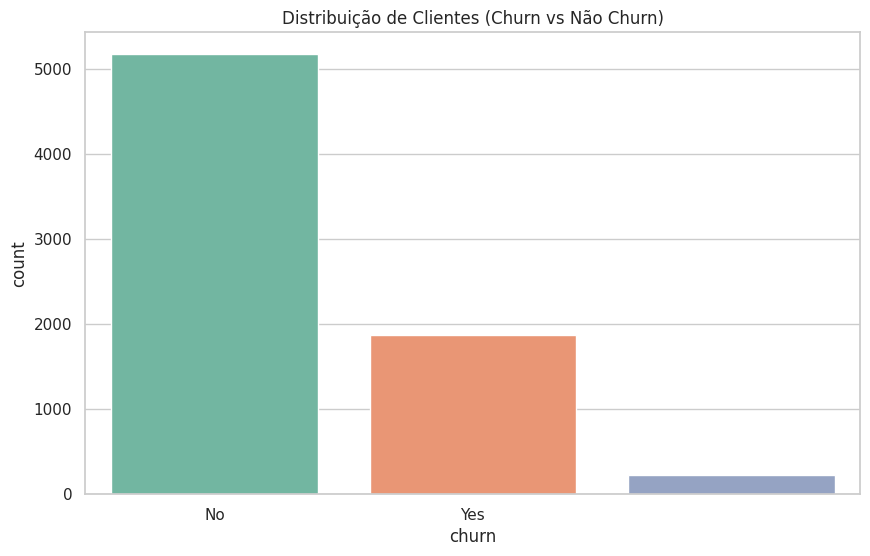

In [1]:
# ============================================
# Telecom X - Desafio Alura
# ============================================

# Introdução
from IPython.display import Markdown

# --------------------------------------------
# 1. Importação das bibliotecas
# --------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# --------------------------------------------
# 2. Extração dos dados (GitHub)
# --------------------------------------------
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
dados = pd.read_json(url)

print("Dados extraídos com sucesso!")
print(dados.head())

# --------------------------------------------
# 3. Transformação dos dados (ETL - limpeza)
# --------------------------------------------
# Verificar valores ausentes
print(dados.isnull().sum())

# Exemplo de tratamento: preencher valores nulos
dados.fillna(method="ffill", inplace=True)

# Padronizar colunas
dados.columns = [col.strip().lower().replace(" ", "_") for col in dados.columns]

# --------------------------------------------
# 4. Análise Exploratória (EDA)
# --------------------------------------------
# Estatísticas descritivas
print(dados.describe())

# Distribuição da variável alvo (churn)
if "churn" in dados.columns:
    sns.countplot(x="churn", data=dados, palette="Set2")
    plt.title("Distribuição de Clientes (Churn vs Não Churn)")
    plt.show()

# Relação entre churn e tipo de contrato
if "contract" in dados.columns:
    sns.countplot(x="contract", hue="churn", data=dados, palette="Set1")
    plt.title("Churn por Tipo de Contrato")
    plt.show()

# Relação entre churn e tempo de permanência
if "tenure" in dados.columns:
    sns.histplot(data=dados, x="tenure", hue="churn", multiple="stack", bins=30)
    plt.title("Tempo de Permanência vs Churn")
    plt.show()

